# Quant Research Notebook

สมุดวิจัยสำหรับระบบ `quant` — โหลดข้อมูล, รัน backtest, เปรียบเทียบกลยุทธ์,
ทำ parameter sweep และ walk-forward validation แบบ interactive

> รันทีละเซลล์จากบนลงล่าง (Shift+Enter) เซลล์แรกตั้ง path + ย้าย working dir ไป project root

In [1]:
import os, sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)               # so "data/" and "results/" resolve here
DATA_DIR = os.path.join(PROJECT_ROOT, "data")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from quant.runner import run_backtest
from quant.strategy.registry import list_strategies
from quant.research.sweep import run_sweep
from quant.research.walkforward import walk_forward
from quant.performance.metrics import drawdown_series, format_stats

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
list_strategies()

{'sma_cross': {'short_window': 50, 'long_window': 200},
 'momentum': {'lookback': 126, 'trend_window': 200},
 'rsi_reversion': {'period': 14, 'oversold': 30.0, 'exit_level': 50.0},
 'bollinger': {'window': 20, 'num_std': 2.0}}

## 1. ข้อมูล — โหลด (ดาวน์โหลดอัตโนมัติถ้ายังไม่มี)

In [2]:
from quant.data.loaders import download_to_parquet

SYMBOLS = ["AAPL", "MSFT", "SPY"]
START, END = "2015-01-01", "2024-12-31"

missing = [s for s in SYMBOLS if not os.path.exists(os.path.join(DATA_DIR, f"{s}.parquet"))]
if missing:
    print("Downloading:", missing)
    download_to_parquet(missing, START, END, DATA_DIR)

prices = {s: pd.read_parquet(os.path.join(DATA_DIR, f"{s}.parquet")) for s in SYMBOLS}
prices["SPY"].tail()

,open,high,low,close,volume
timestamp,,,,,
2024-12-23,582.4411,586.7880,579.2572,586.1867,57635800
2024-12-24,587.5371,592.7416,586.9555,592.7021,33160100
2024-12-26,590.9279,593.8652,589.5282,592.7416,41219100
2024-12-27,588.9958,589.2324,582.3128,586.5020,64969300
2024-12-30,579.4840,583.2789,576.0537,579.8092,56578800


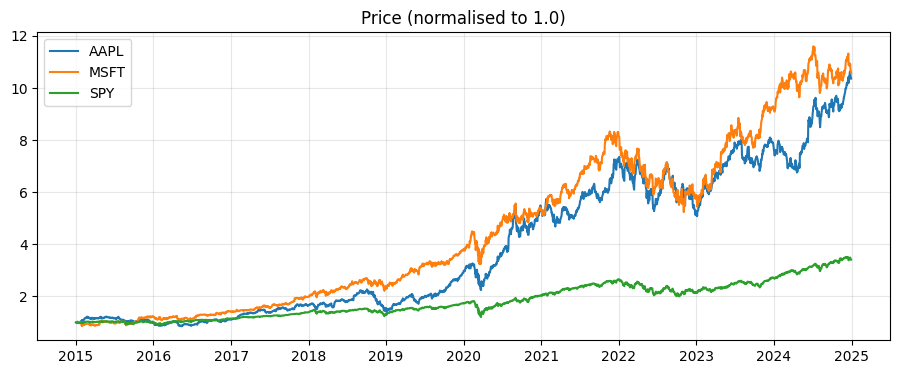

In [3]:
plt.figure(figsize=(11, 4))
for s in SYMBOLS:
    c = prices[s]["close"]
    plt.plot(c.index, c / c.iloc[0], label=s)   # normalise to 1.0 at start
plt.legend(); plt.title("Price (normalised to 1.0)"); plt.grid(alpha=0.3); plt.show()

## 2. Backtest กลยุทธ์เดียว

In [4]:
res = run_backtest(SYMBOLS, START, END, strategy="sma_cross",
                   strategy_params={"short_window": 50, "long_window": 200},
                   data_dir=DATA_DIR)
print(format_stats(res.stats, 100_000))

  Start equity      : 100,000.00
  Final equity      : 185,657.71
  Total return      : 85.66%
  CAGR              : 6.40%
  Annual volatility : 7.47%
  Sharpe ratio      : 0.87
  Sortino ratio     : 0.97
  Max drawdown      : -11.88%
  Calmar ratio      : 0.54
  Bars              : 2515


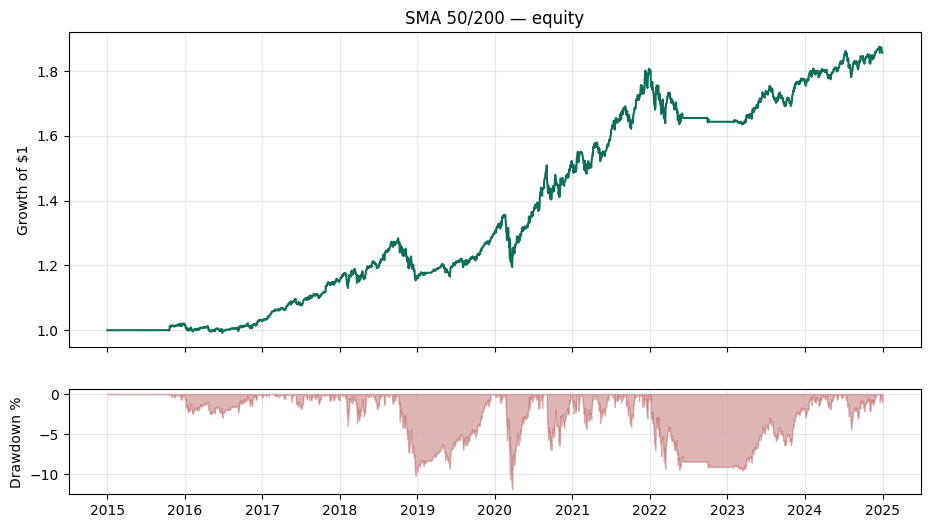

In [5]:
eq = res.equity_curve
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1]})
a1.plot(eq.index, eq["equity_curve"], color="#0F6E56"); a1.set_title("SMA 50/200 — equity")
a1.set_ylabel("Growth of $1"); a1.grid(alpha=0.3)
dd = drawdown_series(eq["equity_curve"]) * 100
a2.fill_between(dd.index, dd.values, 0, color="#A32D2D", alpha=0.35)
a2.set_ylabel("Drawdown %"); a2.grid(alpha=0.3)
plt.show()

## 3. เปรียบเทียบหลายกลยุทธ์

In [6]:
configs = {
    "SMA 50/200":    ("sma_cross",     {"short_window": 50, "long_window": 200}),
    "Momentum":      ("momentum",      {"lookback": 126, "trend_window": 200}),
    "RSI reversion": ("rsi_reversion", {"period": 14, "oversold": 30, "exit_level": 55}),
    "Bollinger":     ("bollinger",     {"window": 20, "num_std": 2.0}),
}

rows, curves = [], {}
for name, (strat, params) in configs.items():
    r = run_backtest(SYMBOLS, START, END, strategy=strat, strategy_params=params, data_dir=DATA_DIR)
    curves[name] = r.equity_curve["equity_curve"]
    rows.append({"strategy": name,
                 **{k: r.stats.get(k) for k in ["total_return", "cagr", "sharpe", "max_drawdown"]}})

comparison = pd.DataFrame(rows).set_index("strategy")
comparison

,total_return,cagr,sharpe,max_drawdown
strategy,,,,
SMA 50/200,0.8566,0.0640,0.8669,-0.1188
Momentum,0.6502,0.0515,0.8971,-0.1217
RSI reversion,0.1178,0.0112,0.4350,-0.0557
Bollinger,0.2353,0.0214,0.5755,-0.0744


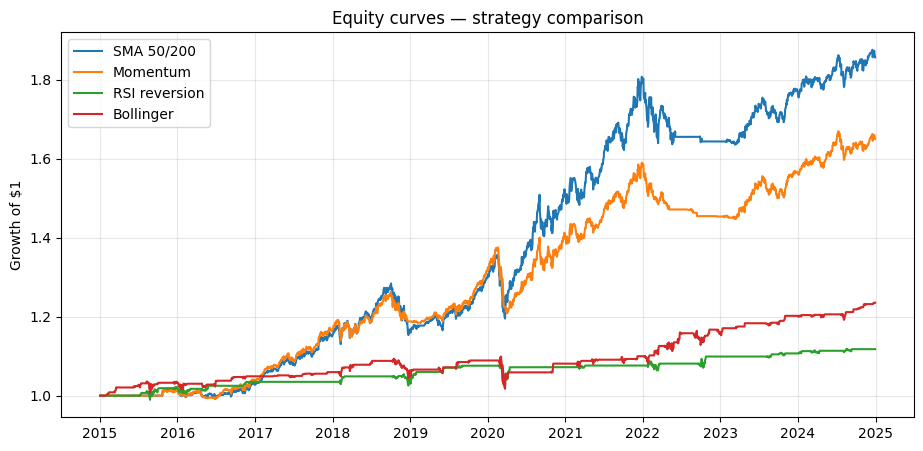

In [7]:
plt.figure(figsize=(11, 5))
for name, c in curves.items():
    plt.plot(c.index, c.values, label=name)
plt.legend(); plt.title("Equity curves — strategy comparison")
plt.ylabel("Growth of $1"); plt.grid(alpha=0.3); plt.show()

## 4. Parameter sweep + heatmap

In [8]:
sweep = run_sweep(["SPY"], START, END, "sma_cross",
                  {"short_window": [20, 50, 100], "long_window": [150, 200, 250]},
                  data_dir=DATA_DIR)
sweep.sort_values("sharpe", ascending=False).head()

,short_window,long_window,total_return,cagr,ann_volatility,sharpe,sortino,max_drawdown,calmar,bars,final_equity,n_fills
5,50,250,0.1161,0.0111,0.0159,0.6998,0.6850,-0.0399,0.2774,2515,"111,612.3468",9
2,20,250,0.1103,0.0105,0.0153,0.6939,0.6688,-0.0348,0.3027,2515,"111,032.5374",13
1,20,200,0.1059,0.0101,0.0150,0.6805,0.6554,-0.0415,0.2443,2515,"110,592.6203",13
7,100,200,0.1134,0.0108,0.0161,0.6778,0.6614,-0.0396,0.2728,2515,"111,335.6208",7
4,50,200,0.1095,0.0105,0.0156,0.6770,0.6634,-0.0398,0.2627,2515,"110,951.0793",9


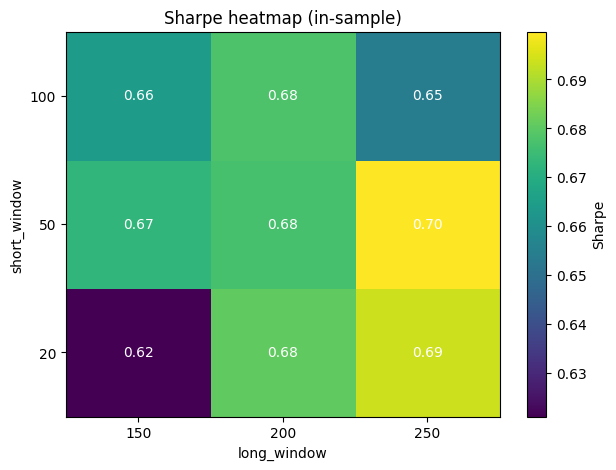

In [9]:
pivot = sweep.pivot_table(index="short_window", columns="long_window", values="sharpe")
plt.figure(figsize=(7, 5))
plt.imshow(pivot.values, cmap="viridis", origin="lower", aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if v == v:
            plt.text(j, i, f"{v:.2f}", ha="center", va="center", color="white")
plt.colorbar(label="Sharpe"); plt.xlabel("long_window"); plt.ylabel("short_window")
plt.title("Sharpe heatmap (in-sample)"); plt.show()

## 5. Walk-forward validation

เลือกพารามิเตอร์ที่ดีที่สุดบนช่วง train แล้ววัดผลบนช่วง test ที่ไม่เคยเห็น
ตัวเลข out-of-sample ที่ต่อกัน = ค่าที่ "ซื่อสัตย์" ที่สุด ใกล้เคียงการเทรดจริงมากกว่า in-sample

In [10]:
wf = walk_forward(["SPY"], START, END, "sma_cross",
                  {"short_window": [20, 50, 100], "long_window": [150, 200, 250]},
                  train_years=3, test_years=1, metric="sharpe", data_dir=DATA_DIR)
wf["windows"]

,train_start,train_end,test_start,test_end,best_short_window,best_long_window,oos_total_return,oos_cagr,oos_sharpe,oos_max_drawdown
0,2015-01-01,2018-01-01,2018-01-01,2019-01-01,100.0000,250.0000,-0.0067,-0.0068,-0.2992,-0.0270
1,2016-01-01,2019-01-01,2019-01-01,2020-01-01,20.0000,200.0000,0.0172,0.0172,1.4840,-0.0069
2,2017-01-01,2020-01-01,2020-01-01,2021-01-01,50.0000,150.0000,-0.0038,-0.0038,-0.1175,-0.0403
3,2018-01-01,2021-01-01,2021-01-01,2022-01-01,100.0000,250.0000,0.0328,0.0328,2.0651,-0.0066
4,2019-01-01,2022-01-01,2022-01-01,2023-01-01,20.0000,150.0000,-0.0169,-0.0169,-1.6242,-0.0182
5,2020-01-01,2023-01-01,2023-01-01,2024-01-01,50.0000,200.0000,0.0189,0.0190,1.4932,-0.0110
6,2021-01-01,2024-01-01,2024-01-01,2024-12-31,50.0000,150.0000,0.0259,0.0260,1.8133,-0.0099


  Start equity      : 100,000.00
  Final equity      : 106,821.51
  Total return      : 6.82%
  CAGR              : 0.95%
  Annual volatility : 1.76%
  Sharpe ratio      : 0.55
  Sortino ratio     : 0.56
  Max drawdown      : -4.03%
  Calmar ratio      : 0.24
  Bars              : 1760


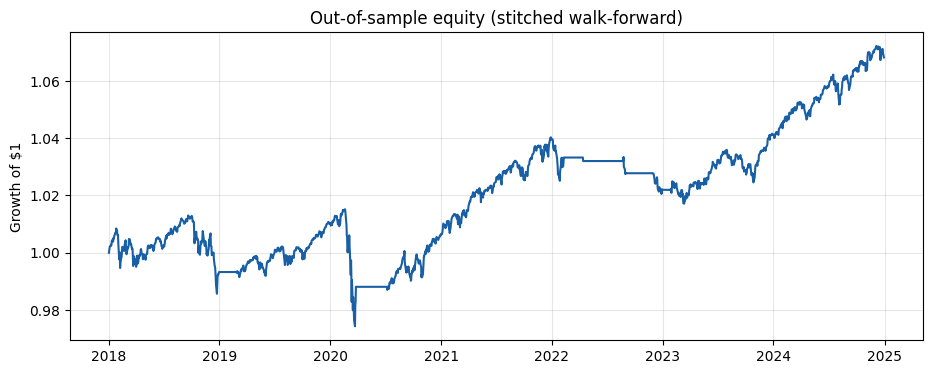

In [11]:
print(format_stats(wf["overall"], 100_000))
c = wf["combined"]
plt.figure(figsize=(11, 4))
plt.plot(c.index, c["equity_curve"], color="#185FA5")
plt.title("Out-of-sample equity (stitched walk-forward)")
plt.ylabel("Growth of $1"); plt.grid(alpha=0.3); plt.show()

## ทำต่อจากนี้

- เปลี่ยน `SYMBOLS`, ช่วงวันที่, หรือ `strategy_params` แล้วรันใหม่
- เพิ่มกลยุทธ์ของคุณเองใน `quant/strategy/examples.py` แล้วลงทะเบียนใน `quant/strategy/registry.py`
- เทียบ in-sample (ส่วนที่ 4) กับ out-of-sample (ส่วนที่ 5) เสมอ ก่อนเชื่อกลยุทธ์ใด ๆ